# **RandomForest**

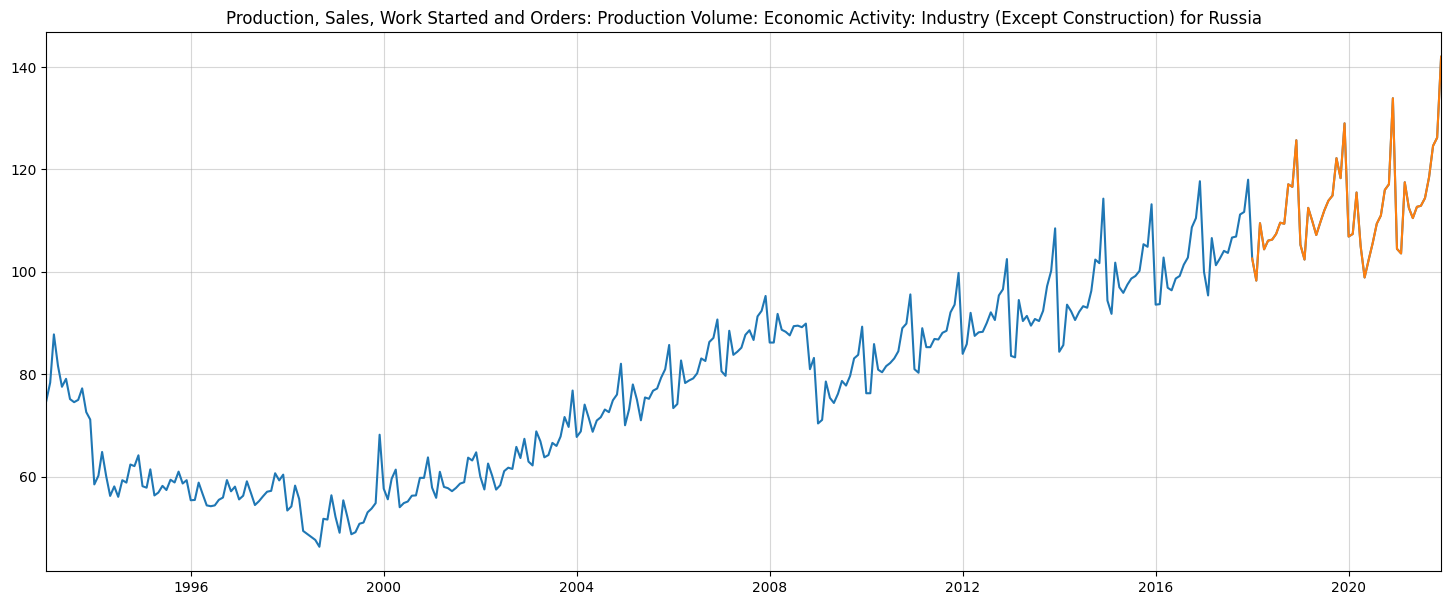

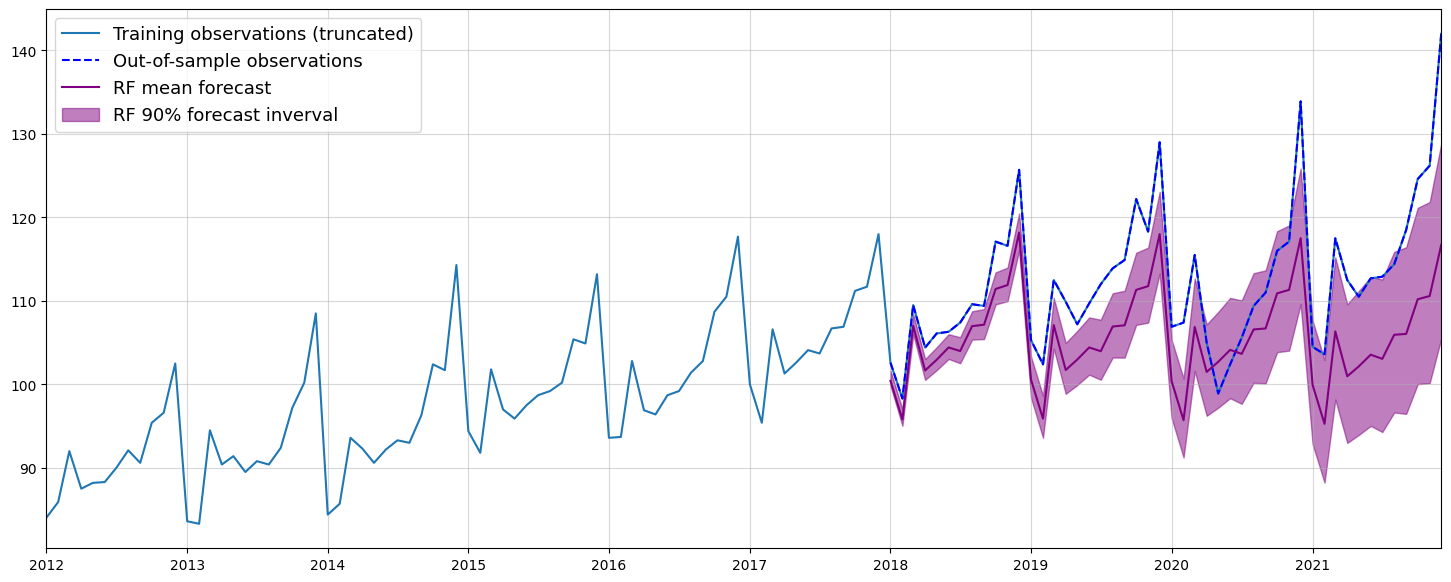

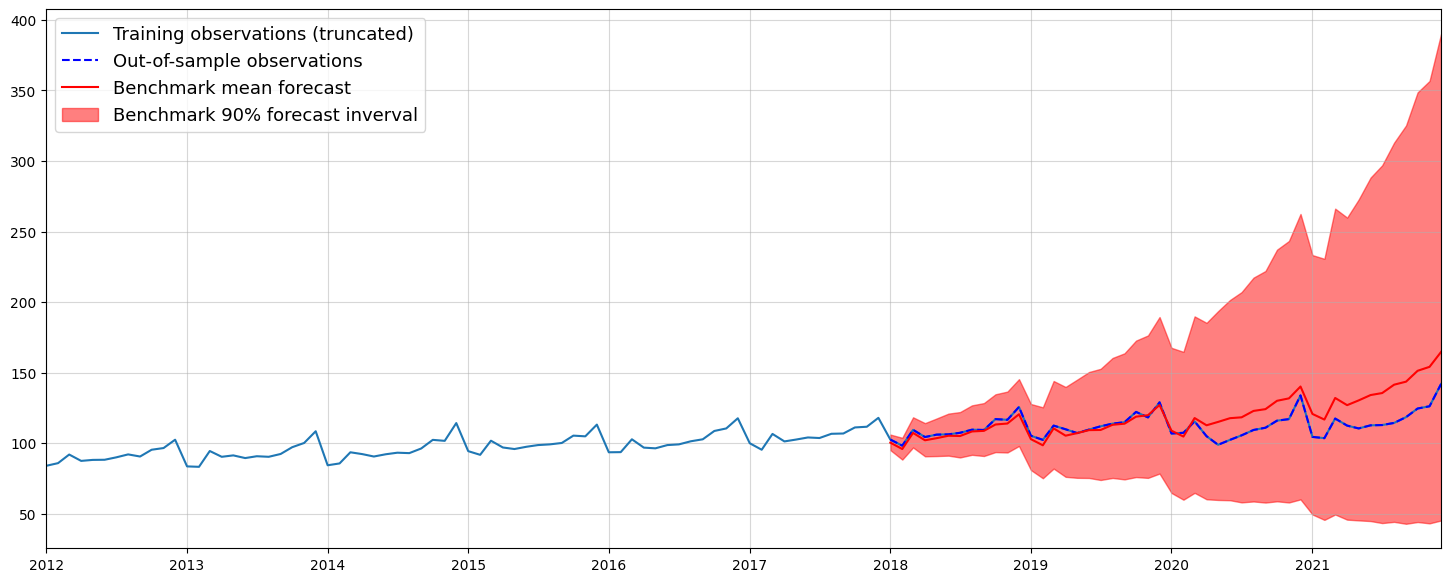

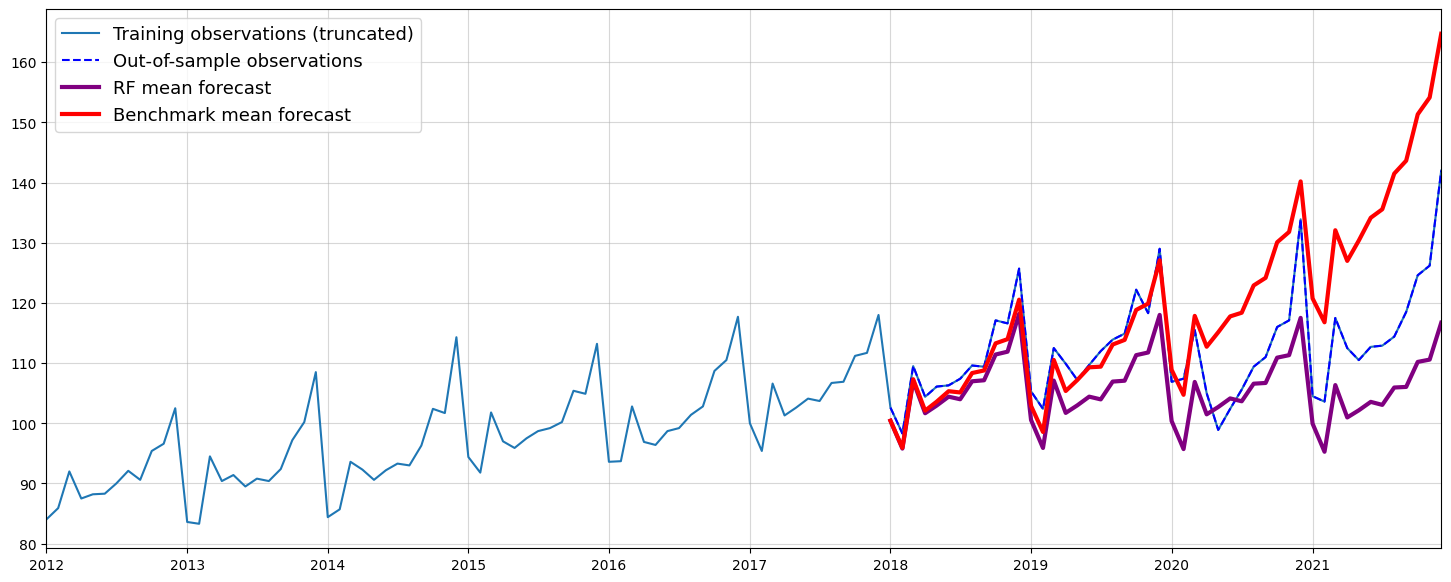

Random Forest: 8.40625702497976
Benchmark: 12.340001849178877


In [11]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import datetime

#RUSPRINTO01IXOBM
start = datetime.datetime(1993, 1, 1)
end = datetime.datetime(2021, 12, 1)
df = web.DataReader('RUSPRINTO01IXOBM', 'fred', start, end)

df_train = df.iloc[:-48]
df_test = df.iloc[-48:]

plt.figure(figsize = (18,7))
plt.plot(df, label="Training data")
plt.plot(df_test, label = "Test data")
plt.grid(alpha=0.5)
plt.margins(x=0)
plt.title("Production, Sales, Work Started and Orders: Production Volume: Economic Activity: Industry (Except Construction) for Russia")
plt.show()

from sklearn.ensemble import RandomForestRegressor
from copy import deepcopy


class RandomForestARModel():
    """
    Autoregressive forecasting with Random Forests
    """

    def __init__(self, n_lags=1, max_depth = 1, n_estimators=1000, random_state = 123,
                 log_transform = False, first_differences = False, seasonal_differences = None):
        """
        Args:
            n_lags: Number of lagged features to consider in autoregressive model
            max_depth: Max depth for the forest's regression trees
            random_state: Random state to pass to random forest

            log_transform: Whether the input should be log-transformed
            first_differences: Whether the input should be singly differenced
            seasonal_differences: Seasonality to consider, if 'None' then no seasonality is presumed
        """

        self.n_lags = n_lags
        self.model = RandomForestRegressor(max_depth = max_depth, n_estimators = n_estimators, random_state = random_state)

        self.log_transform = log_transform
        self.first_differences = first_differences
        self.seasonal_differences = seasonal_differences



    def fit(self, y):
        """
        Args:
            y: training data (numpy array or pandas series/dataframe)
        """
        #enable pandas functions via dataframes
        y_df = pd.DataFrame(y)
        self.y_df = deepcopy(y_df)

        #apply transformations and store results for retransformations
        if self.log_transform:
            y_df = np.log(y_df)
            self.y_logged = deepcopy(y_df)

        if self.first_differences:
            y_df = y_df.diff().dropna()
            self.y_diffed = deepcopy(y_df)

        if self.seasonal_differences is not None:
            y_df = y_df.diff(self.seasonal_differences).dropna()
            self.y_diffed_seasonal = deepcopy(y_df)


        #get lagged features
        Xtrain = pd.concat([y_df.shift(t) for t in range(1,self.n_lags+1)],axis=1).dropna()
        self.Xtrain = Xtrain

        ytrain = y_df.loc[Xtrain.index,:]
        self.ytrain = ytrain
        self.model.fit(Xtrain.values,ytrain.values.reshape(-1))


    def sample_forecast(self, n_periods = 1, n_samples = 10000, random_seed =123):
        """
        Draw forecasting samples by randomly drawing from all trees in the forest per forecast period
        Args:
            n_periods: Ammount of periods to forecast
            n_samples: Number of samples to draw
            random_seed: Random seed for numpy
        """
        samples = self._perform_forecast(n_periods, n_samples, random_seed)
        output = self._retransform_forecast(samples, n_periods)

        return output



    def _perform_forecast(self, n_periods, n_samples, random_seed):
        """
        Forecast transformed observations
        Args:
            n_periods: Ammount of periods to forecast
            n_samples: Number of samples to draw
            random_seed: Random seed for numpy
        """
        samples = []

        np.random.seed(random_seed)
        for i in range(n_samples):
            #store lagged features for each period
            Xf = np.concatenate([self.Xtrain.iloc[-1,1:].values.reshape(1,-1),
                                 self.ytrain.iloc[-1].values.reshape(1,1)],1)
            forecasts = []
            for t in range(n_periods):
                tree = self.model.estimators_[np.random.randint(len(self.model.estimators_))]
                pred = tree.predict(Xf)[0]
                forecasts.append(pred)

                #update lagged features for next period
                Xf = np.concatenate([Xf[:,1:],np.array([[pred]])],1)

            samples.append(forecasts)

        return samples



    def _retransform_forecast(self, samples, n_periods):
        """
        Retransform forecast (re-difference and exponentiate)
        Args:
            samples: Forecast samples for retransformation
            n_periods: Ammount of periods to forecast
        """

        full_sample_tree = []
        for samp in samples:
            draw = np.array(samp)

            #retransform seasonal differencing
            if self.seasonal_differences is not None:
                result = list(self.y_diffed.iloc[-self.seasonal_differences:].values)
                for t in range(n_periods):
                    result.append(result[t]+draw[t])
                result = result[self.seasonal_differences:]
            else:
                result = []
                for t in range(n_periods):
                    result.append(draw[t])

            #retransform first differences
            y_for_add = self.y_logged.values[-1] if self.log_transform else self.y_df.values[-1]

            if self.first_differences:
                result = y_for_add + np.cumsum(result)

            #retransform log transformation
            if self.log_transform:
                result = np.exp(result)

            full_sample_tree.append(result.reshape(-1,1))
        return np.concatenate(full_sample_tree,1)



model = RandomForestARModel(n_lags = 2, log_transform = True, first_differences = True, seasonal_differences = 12)
model.fit(df_train)

predictions_forest = model.sample_forecast(n_periods=len(df_test), n_samples=10000)


means_forest = np.mean(predictions_forest,1)
lowers_forest = np.quantile(predictions_forest,0.05,1)
uppers_forest = np.quantile(predictions_forest,0.95,1)

plt.figure(figsize = (18,7))

plt.grid(alpha=0.5)

plt.plot(df.iloc[-120:], label = "Training observations (truncated)")
plt.plot(df_test, color = "blue", label = "Out-of-sample observations", ls="dashed")

plt.plot(df_test.index,means_forest,color="purple", label = "RF mean forecast")

plt.fill_between(df_test.index, lowers_forest, uppers_forest, color="purple", alpha=0.5, label = "RF 90% forecast inverval")

plt.legend(fontsize=13)
plt.margins(x=0)
plt.show()



# Benchmark

from scipy.stats import gaussian_kde

df_train_diffed = np.log(df_train['RUSPRINTO01IXOBM']).diff().dropna()
df_train_trans = df_train_diffed.diff(12).dropna()

kde = gaussian_kde(df_train_trans.values)

target_range = np.linspace(np.min(df_train_trans.values)-0.5,np.max(df_train_trans.values)+0.5,num=100)

full_sample_toy = []
np.random.seed(123)
for i in range(10000):
    draw = kde.resample(len(df_test)).reshape(-1)
    result = list(df_train_diffed.iloc[-12:].values)
    for t in range(len(df_test)):
        result.append(result[t]+draw[t])
    full_sample_toy.append(np.exp(np.array((np.log(df_train.values[-1])+np.cumsum(result[12:]))).reshape(-1,1)))


predictions_toy = np.concatenate(full_sample_toy,1)
means_toy = np.mean(predictions_toy,1)
lowers_toy = np.quantile(predictions_toy,0.05,1)
uppers_toy = np.quantile(predictions_toy,0.95,1)

plt.figure(figsize = (18,7))

plt.grid(alpha=0.5)

plt.plot(df.iloc[-120:], label = "Training observations (truncated)")
plt.plot(df_test, color = "blue", label = "Out-of-sample observations", ls="dashed")

plt.plot(df_test.index,means_toy,color="red", label = "Benchmark mean forecast")

plt.fill_between(df_test.index, lowers_toy, uppers_toy, color="red", alpha=0.5, label = "Benchmark 90% forecast inverval")

plt.legend(fontsize=13)
plt.margins(x=0)
plt.show()

# compare
plt.figure(figsize = (18,7))

plt.grid(alpha=0.5)

plt.plot(df.iloc[-120:], label = "Training observations (truncated)")
plt.plot(df_test, color = "blue", label = "Out-of-sample observations", ls="dashed")

plt.plot(df_test.index,means_forest,color="purple", label = "RF mean forecast",lw = 3)
plt.plot(df_test.index,means_toy,color="red", label = "Benchmark mean forecast", lw = 3)

plt.legend(fontsize=13)
plt.margins(x=0)
plt.show()

rmse_forest = np.sqrt(np.mean((df_test.values[:,0] - means_forest)**2))
rmse_toy = np.sqrt(np.mean((df_test.values[:,0] - means_toy)**2))

print("Random Forest: {}".format(rmse_forest))
print("Benchmark: {}".format(rmse_toy))


На первом графике представлен анализ временных рядов: сплошная синяя линия отображает обучающую выборку, пунктирная синяя — тестовую, красная линия — прогноз, построенный эталонной моделью, а красная заштрихованная область иллюстрирует 90%-ный доверительный интервал. Видно, что с увеличением горизонта прогнозирования диапазон неопределённости расширяется, что свидетельствует о снижении точности предсказаний.
Второй график демонстрирует сравнительный анализ двух прогнозных моделей: одна представлена фиолетовой линией (модель случайного леса), другая — красной (базовая модель). Наряду с этим показаны реальные данные, включая фактические значения вне обучающей выборки (пунктирная синяя линия). Видно, что прогноз случайного леса в целом занижен по сравнению с эталонной моделью и фактическими значениями.
Погрешность модели случайного леса составляет 8,41, тогда как базовая модель показывает ошибку 12,34. Это означает, что случайный лес обеспечивает более точные прогнозы по сравнению с эталоном в данном случае.

# **TreeBasedForecasting_seasonal**

[*********************100%***********************]  1 of 1 completed


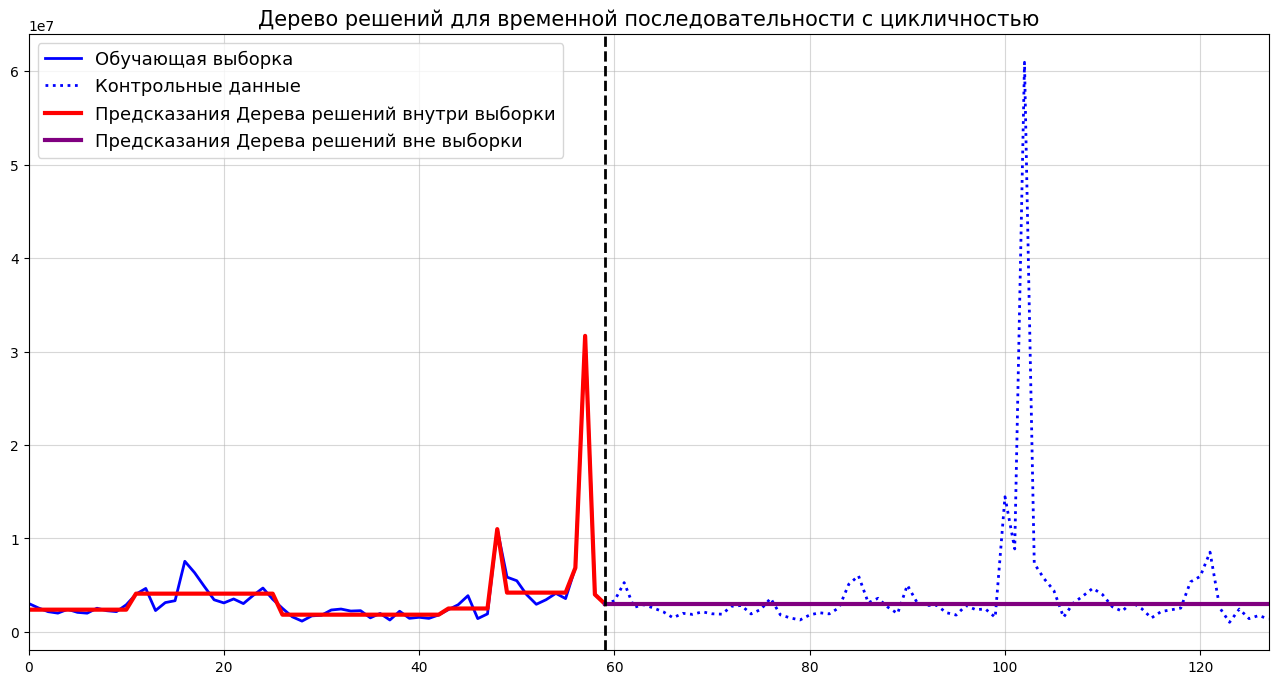

In [6]:
import numpy as np
import pandas_datareader.data as web
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import datetime

import yfinance as yf
nvda = yf.download("FLEX", '2024-07-01', '2025-01-01')

t = np.arange(len(nvda))
y = nvda['Volume'].values

t_train = t[:60].reshape(-1,1)
t_test = t[60:].reshape(-1,1)

y_train = y[:60]
y_test = y[60:]

tree = DecisionTreeRegressor(max_depth = 4)
tree.fit(t_train, y_train)

y_pred_train = tree.predict(t_train)
y_pred_test = tree.predict(t_test)

plt.figure(figsize = (16,8))
plt.plot(t_train.reshape(-1), y_train, label = "Обучающая выборка", color="blue", lw=2)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_train[-1]],y_test]), label = "Контрольные данные",
         color="blue", ls = "dotted", lw=2)


plt.plot(t_train.reshape(-1), y_pred_train, label = "Предсказания Дерева решений внутри выборки",
         color="red", lw = 3)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_pred_train[-1]],y_pred_test]), label = "Предсказания Дерева решений вне выборки",
         color="purple", lw=3)

plt.grid(alpha = 0.5)
plt.axvline(t_train[-1], color="black", lw=2, ls="dashed")
plt.legend(fontsize=13)
plt.title("Дерево решений для временной последовательности с цикличностью", fontsize=15)

plt.margins(x=0)
plt.show()

График иллюстрирует слабые стороны модели дерева решений при работе с временными рядами, обладающими цикличностью. Хотя модель демонстрирует приемлемые результаты на обучающей выборке, её способность к обобщению на новых, ранее не встречавшихся данных ограничена. Несмотря на схожий масштаб и тренды в тестовом наборе, модель не справляется с точным прогнозированием. Особенно это заметно в районе x = 100, где наблюдается резкий пик, полностью упущенный моделью, что указывает на то, что подобные аномалии выходят за рамки её возможностей по моделированию.

# **TreeBasedForecasting_autoregressive2**

<ipython-input-7-8de06ac96722>:12: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  df000 = df.resample('Q', convention='start').last().dropna()
<ipython-input-7-8de06ac96722>:12: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df000 = df.resample('Q', convention='start').last().dropna()


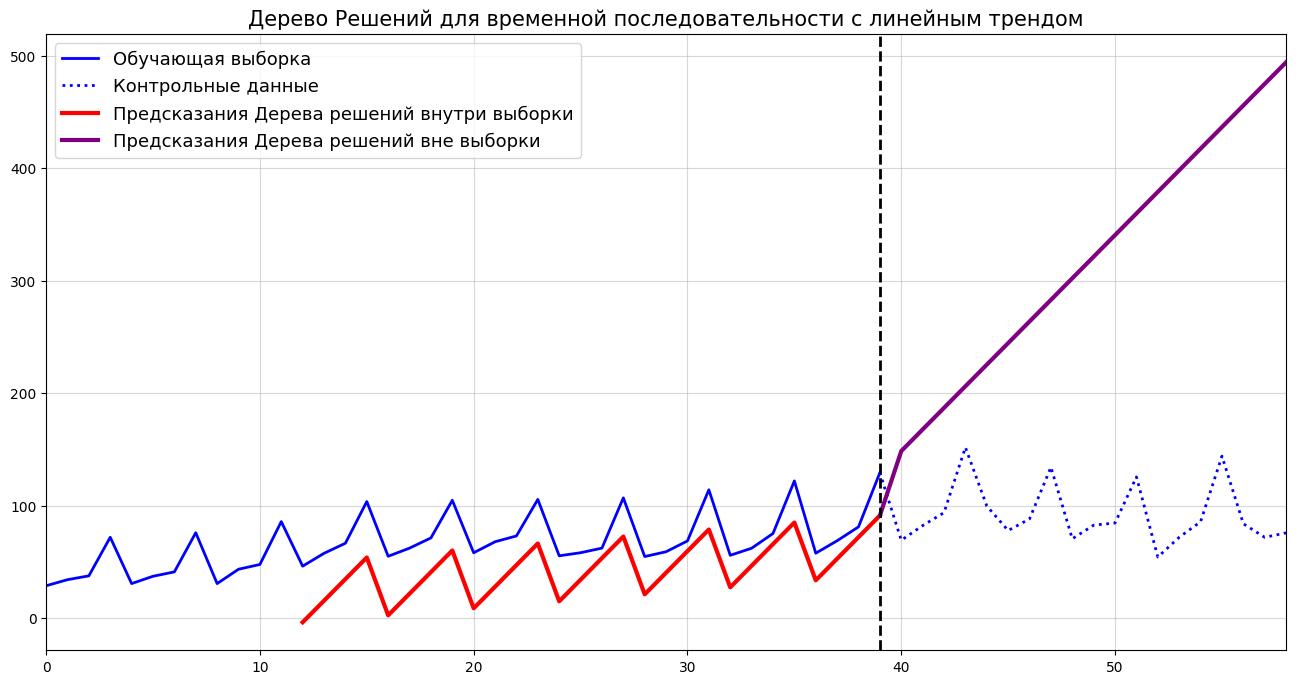

In [7]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import datetime

start = datetime.datetime(1999, 12, 1)
end = datetime.datetime(2019, 12, 1)
df = web.DataReader('RUSPRCNTO01IXOBQ', 'fred', start, end)

df000 = df.resample('Q', convention='start').last().dropna()

t = np.arange(len(df000))
y = df000.iloc[:,0].values

t_train = t[:40].reshape(-1,1)
t_test = t[40:].reshape(-1,1)

n_lags = 12

y_train = y[:40]
X_train_shift = pd.concat([pd.DataFrame(y_train).shift(t) for t in range(1,n_lags)],axis=1).diff().values[n_lags:,:]
y_train_shift = np.diff(y_train)[n_lags-1:]
y_test = y[40:]

tree = DecisionTreeRegressor(max_depth = 1)
tree.fit(X_train_shift, y_train_shift)

y_pred_train = tree.predict(X_train_shift).reshape(-1)

Xt = np.concatenate([X_train_shift[-1,1:].reshape(1,-1),np.array(y_train_shift[-1]).reshape(1,1)],1)
predictions_test = []

for t in range(len(y_test)):
    pred = tree.predict(Xt)
    predictions_test.append(pred[0])
    Xt = np.concatenate([np.array(pred).reshape(1,1),Xt[-1,1:].reshape(1,-1)],1)

y_pred_test = np.array(predictions_test)

y_pred_train = y_train[n_lags-2]+np.cumsum(y_pred_train)
y_pred_test = y_train[-1]+np.cumsum(y_pred_test)

plt.figure(figsize = (16,8))
plt.plot(t_train.reshape(-1), y_train, label = "Обучающая выборка", color="blue", lw=2)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_train[-1]],y_test]), label = "Контрольные данные",
         color="blue", ls = "dotted", lw=2)


plt.plot(t_train.reshape(-1)[n_lags:], y_pred_train, label = "Предсказания Дерева решений внутри выборки",
         color="red", lw = 3)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_pred_train[-1]],y_pred_test]), label = "Предсказания Дерева решений вне выборки",
         color="purple", lw=3)

plt.grid(alpha = 0.5)
plt.axvline(t_train[-1], color="black", lw=2, ls="dashed")
plt.legend(fontsize=13)
plt.title("Дерево Решений для временной последовательности с линейным трендом", fontsize=15)

plt.margins(x=0)
plt.show()


Прогнозы, построенные на основе обучающей выборки, частично совпадают с исходными данными, однако ступенчатый характер красной линии говорит о том, что модель дерева решений неспособна точно отразить сложную структуру временного ряда. Особенно это касается мелких циклических колебаний, которые сглаживаются или вовсе игнорируются — модель лишь приближённо воспроизводит поведение реального процесса.
Что касается общего направления данных, то оно характеризуется положительным линейным трендом. Модель улавливает этот тренд, что можно увидеть по наклону фиолетовой линии — она отражает общую тенденцию роста, но не отображает детали. Это связано с тем, что дерево решений склонно описывать общие закономерности, а не нюансировать локальные изменения.
Кроме того, дерево решений ограничено в способности к экстраполяции: оно не может предсказать значения, выходящие за пределы диапазона обучающих данных. Поэтому резкие пики и падения в тестовой выборке интерпретируются как шум, а не как закономерная часть структуры временного ряда. В результате линейный тренд становится доминирующим фактором в прогнозах, тогда как циклические изменения теряются.

# **TreeBasedForecasting_autoregressive1**

<ipython-input-8-9e3dab453660>:12: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  df000 = df.resample('Q', convention='start').last().dropna()
<ipython-input-8-9e3dab453660>:12: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df000 = df.resample('Q', convention='start').last().dropna()


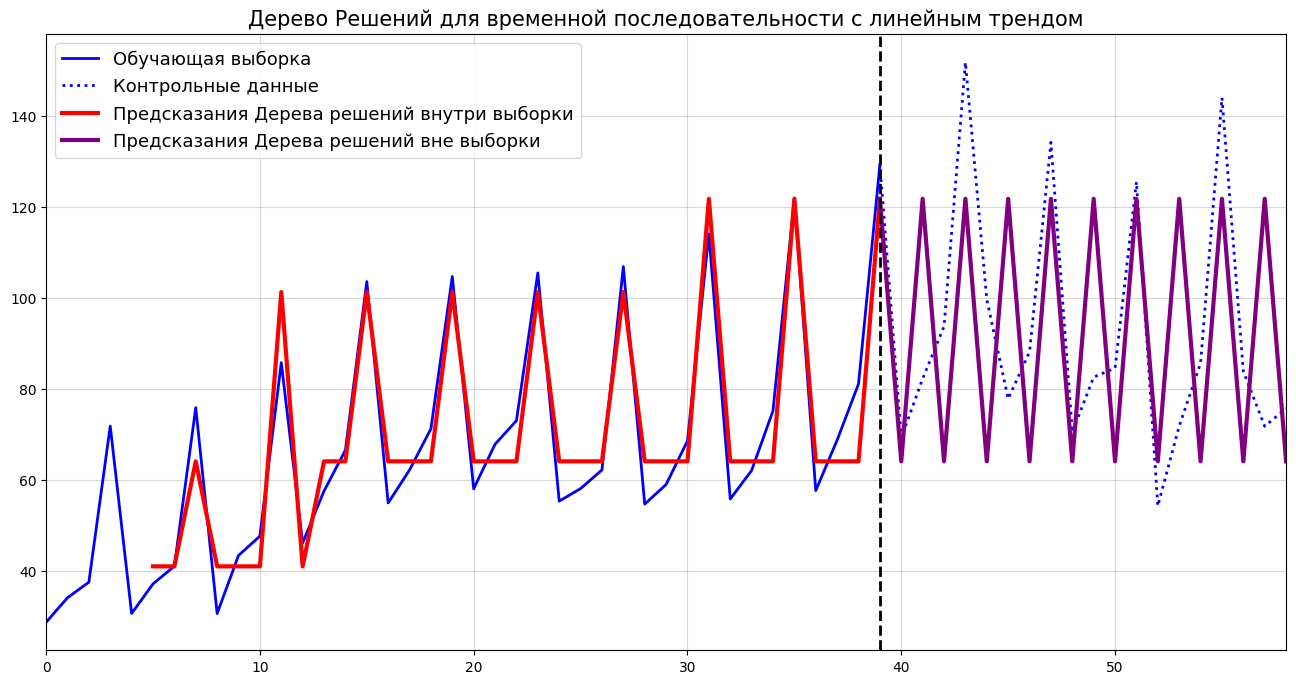

In [8]:
import pandas as pd
import numpy as np
import pandas_datareader.data as web
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import datetime

start = datetime.datetime(1999, 12, 1)
end = datetime.datetime(2019, 12, 1)
df = web.DataReader('RUSPRCNTO01IXOBQ', 'fred', start, end)

df000 = df.resample('Q', convention='start').last().dropna()

t = np.arange(len(df000))
y = df000.iloc[:,0].values

t_train = t[:40].reshape(-1,1)
t_test = t[40:].reshape(-1,1)

y_train = y[:40]
X_train_shift = np.concatenate([pd.Series(y_train).shift(t).values.reshape(-1,1) for t in range(1,6)],1)[5:,:]
y_train_shift = y_train[5:]
y_test = y[40:]

tree = DecisionTreeRegressor(max_depth = 2)
tree.fit(X_train_shift, y_train_shift)

y_pred_train = tree.predict(X_train_shift).reshape(-1)

Xt = np.concatenate([X_train_shift[-1,1:].reshape(1,-1),np.array(y_train_shift[-1]).reshape(1,1)],1)
predictions_test = []

for t in range(len(y_test)):
    pred = tree.predict(Xt)
    predictions_test.append(pred[0])
    Xt = np.concatenate([Xt[-1,1:].reshape(1,-1),np.array(pred).reshape(1,1)],1)

y_pred_test = np.array(predictions_test)


plt.figure(figsize = (16,8))
plt.plot(t_train.reshape(-1), y_train, label = "Обучающая выборка", color="blue", lw=2)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_train[-1]],y_test]), label = "Контрольные данные",
         color="blue", ls = "dotted", lw=2)


plt.plot(t_train.reshape(-1)[5:], y_pred_train, label = "Предсказания Дерева решений внутри выборки",
         color="red", lw = 3)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_pred_train[-1]],y_pred_test]), label = "Предсказания Дерева решений вне выборки",
         color="purple", lw=3)

plt.grid(alpha = 0.5)
plt.axvline(t_train[-1], color="black", lw=2, ls="dashed")
plt.legend(fontsize=13)
plt.title("Дерево Решений для временной последовательности с линейным трендом", fontsize=15)

plt.margins(x=0)
plt.show()


Прогнозы модели на обучающей выборке лишь частично отражают реальное поведение данных: дерево решений фиксирует основную тенденцию и отдельные колебания, но не способно точно воспроизвести всю структуру временного ряда, особенно его циклические или нестабильные элементы.
Модель разбивает данные на ограниченное количество интервалов, в пределах которых делает постоянные предсказания. Визуально это проявляется в виде ступенчатой формы прогноза (красной линии), что снижает его точность и делает модель нечувствительной к плавным изменениям.
На тестовых данных ситуация ещё хуже: прогноз вне выборки полностью расходится с реальными значениями и демонстрирует линейный рост, игнорируя фактические колебания. Это свидетельствует о слабой способности модели к экстраполяции и низкой обобщающей способности при работе с новыми данными.

# **TreeBasedForecasting**

<ipython-input-9-d39278bfcc86>:11: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  df000 = df.resample('Q', convention='start').last().dropna()
<ipython-input-9-d39278bfcc86>:11: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df000 = df.resample('Q', convention='start').last().dropna()


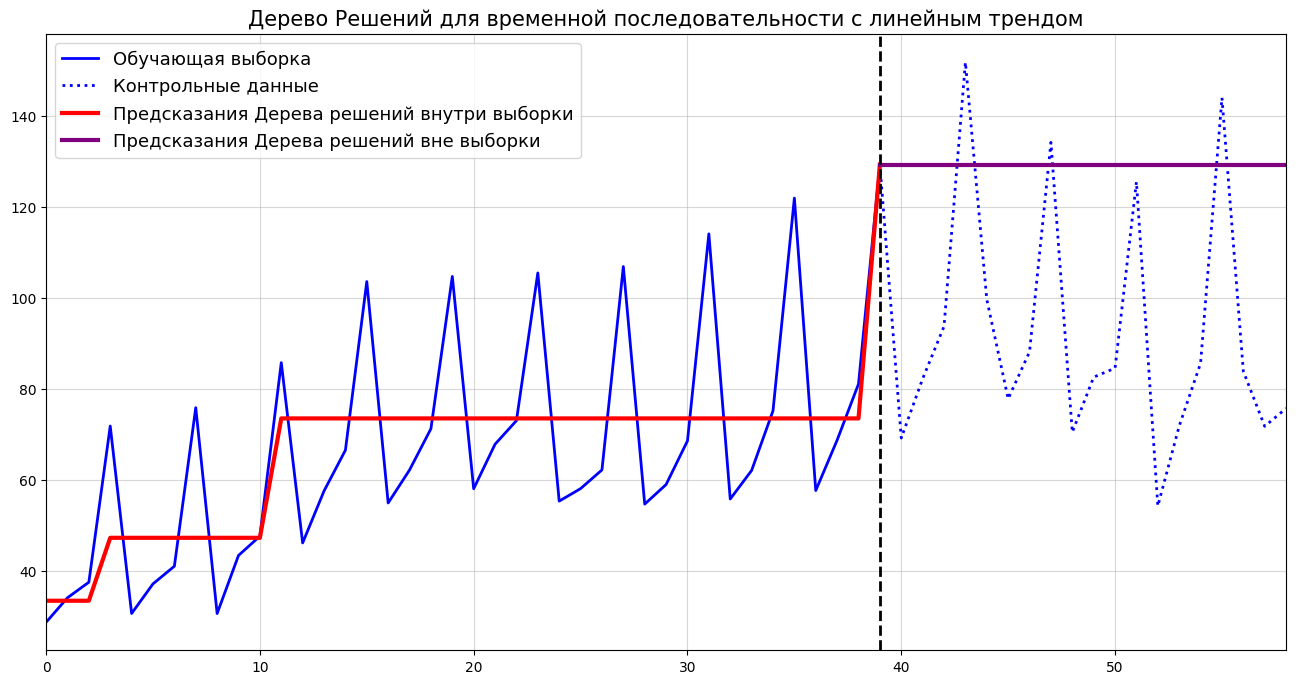

In [9]:
import numpy as np
import pandas_datareader.data as web
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import datetime

start = datetime.datetime(1999, 12, 1)
end = datetime.datetime(2019, 12, 1)
df = web.DataReader('RUSPRCNTO01IXOBQ', 'fred', start, end)

df000 = df.resample('Q', convention='start').last().dropna()

t = np.arange(len(df000))
y = df000.values

t_train = t[:40].reshape(-1,1)
t_test = t[40:].reshape(-1,1)

y_train = y[:40]
y_test = y[40:]

tree = DecisionTreeRegressor(max_depth = 2)
tree.fit(t_train, y_train)

y_pred_train = tree.predict(t_train)
y_pred_test = tree.predict(t_test)

plt.figure(figsize = (16,8))
plt.plot(t_train.reshape(-1), y_train, label = "Обучающая выборка", color="blue", lw=2)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_train[-1]],y_test]), label = "Контрольные данные",
         color="blue", ls = "dotted", lw=2)


plt.plot(t_train.reshape(-1), y_pred_train, label = "Предсказания Дерева решений внутри выборки",
         color="red", lw = 3)
plt.plot(np.concatenate([np.array(t_train[-1]),t_test.reshape(-1)]),
         np.concatenate([[y_pred_train[-1]],y_pred_test]), label = "Предсказания Дерева решений вне выборки",
         color="purple", lw=3)

plt.grid(alpha = 0.5)
plt.axvline(t_train[-1], color="black", lw=2, ls="dashed")
plt.legend(fontsize=13)
plt.title("Дерево Решений для временной последовательности с линейным трендом", fontsize=15)

plt.margins(x=0)

plt.show()

На изображении представлена оценка работы модели дерева решений при прогнозировании временного ряда, содержащего как линейный тренд, так и циклические колебания. Модель, обученная на синей части графика, лишь частично воспроизводит структуру данных: она не способна захватить периодичность и вместо этого выдает кусочно-постоянный прогноз, характерный для деревьев решений.
На отрезке тестовой выборки (обозначенном пунктирной линией) поведение модели ещё менее удовлетворительное — прогноз представлен в виде плоской, неизменной линии, что указывает на неспособность дерева обобщать знания на новые данные. Эта ситуация наглядно демонстрирует ограниченность алгоритма при работе с временными рядами, особенно в условиях сложной динамики.